# In this problem, you will perform K-means clustering manually, with K = 2, on a small example with n = 6 observations and p = 2 features. The observations are as follows.

# (observations)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1, 1, 4],
    [2, 1, 3],
    [3, 0, 4],
    [4, 5, 1],
    [5, 6, 2],
    [6, 4, 0]
])

# (a) Plot the observations.

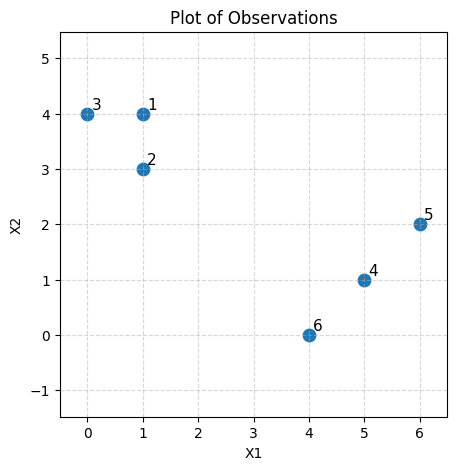

In [3]:
# (a)
obs = X[:,0].astype(int)
X1 = X[:,1]
X2 = X[:,2]

plt.figure(figsize = (5, 5))
plt.scatter(X1, X2, s = 80)

# add labels next to points
for i, (x, y) in enumerate(zip(X1, X2)):
    plt.text(x+0.08, y+0.08, str(obs[i]), fontsize=11)

plt.title("Plot of Observations")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.axis("equal")
plt.xlim(min(X1)-0.5, max(X1)+0.5)
plt.ylim(min(X2)-0.5, max(X2)+0.5)
plt.show()

# (b) Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation.

In [10]:
obs_ids = X[:, 0].astype(int)

# Randomly assign cluster labels {0, 1}; ensure both clusters are represented
rng = np.random.default_rng(42)             # set seed for reproducibility
labels = rng.choice([0, 1], size=len(obs_ids))
while len(np.unique(labels)) < 2:           # re-draw if all fell into one cluster
    labels = rng.choice([0, 1], size=len(obs_ids))

# Report the cluster label for each observation
print("Random initial cluster labels (K=2):")
for oid, lab in zip(obs_ids, labels):
    print(f"Obs {oid}: Cluster {lab}")

Random initial cluster labels (K=2):
Obs 1: Cluster 0
Obs 2: Cluster 1
Obs 3: Cluster 1
Obs 4: Cluster 0
Obs 5: Cluster 0
Obs 6: Cluster 1


# (c) Compute the centroid for each cluster.

In [11]:
# (c)
plot = X[:, 1:3]

# Example: manually assigned cluster labels (0 or 1)
# For instance, maybe observations 1–3 are cluster 0, 4–6 are cluster 1:
labels = np.array([0, 0, 0, 1, 1, 1])

# --- Compute centroids ---
centroids = []
for k in np.unique(labels):
    cluster_points = plot[labels == k]
    centroid = cluster_points.mean(axis=0)
    centroids.append(centroid)
    print(f"Cluster {k}: centroid = {centroid}")

centroids = np.array(centroids)

Cluster 0: centroid = [0.66666667 3.66666667]
Cluster 1: centroid = [5. 1.]


# (d) Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.

In [12]:
# (d)
# ---- (c) result you currently have: a label for each obs (0 or 1) ----
# Replace this with the labels you ended up with after step (b)
labels = np.array([0, 0, 0, 1, 1, 1])

def compute_centroids(points, lbls):
    K = np.unique(lbls)
    cents = np.vstack([points[lbls == k].mean(axis=0) for k in K])
    return cents  # row k corresponds to cluster id in sorted(K)

def assign_to_nearest(points, cents):
    # distances[i, k] = ||points[i] - cents[k]||
    diffs = points[:, None, :] - cents[None, :, :]
    dists = np.linalg.norm(diffs, axis=2)
    return dists.argmin(axis=1)  # nearest centroid index for each point

# centroids from (c)
centroids = compute_centroids(plot, labels)

# ---- (d) assign each observation to the closest centroid ----
new_labels = assign_to_nearest(plot, centroids)

# ---- report ----
print("Centroids (rows = cluster 0, 1):")
print(centroids)
print("\nAssigned cluster for each observation:")
for oid, lab in zip(obs_ids, new_labels):
    print(f"Obs {oid}: Cluster {lab}")

# Optional: check if anything changed relative to previous labels
changed = np.where(new_labels != labels)[0]
print("\nChanged indices:", changed if changed.size else "None")

Centroids (rows = cluster 0, 1):
[[0.66666667 3.66666667]
 [5.         1.        ]]

Assigned cluster for each observation:
Obs 1: Cluster 0
Obs 2: Cluster 0
Obs 3: Cluster 0
Obs 4: Cluster 1
Obs 5: Cluster 1
Obs 6: Cluster 1

Changed indices: None


# (e) Repeat (c) and (d) until the answers obtained stop changing.

In [15]:
# (e)
# ---- Initialize cluster labels randomly (K=2) ----
np.random.seed(42)
labels = np.random.choice([0, 1], size=len(plot))
print("Initial labels:", labels)

def compute_centroids(points, labels):
    """Compute centroid (mean) for each cluster."""
    unique = np.unique(labels)
    cents = np.vstack([points[labels == k].mean(axis=0) for k in unique])
    return cents  # each row = centroid of cluster k

def assign_to_nearest(points, cents):
    """Assign each point to nearest centroid (Euclidean distance)."""
    dists = np.linalg.norm(points[:, None, :] - cents[None, :, :], axis=2)
    return dists.argmin(axis=1)

# ---- Iterate until labels stop changing ----
iteration = 0
while True:
    iteration += 1
    centroids = compute_centroids(plot, labels)
    new_labels = assign_to_nearest(plot, centroids)

    print(f"\nIteration {iteration}")
    print("Centroids:\n", centroids)
    print("Labels:", new_labels)

    # stop if labels no longer change
    if np.array_equal(new_labels, labels):
        print("\nConverged — cluster assignments no longer change.")
        break
    labels = new_labels

Initial labels: [0 1 0 0 0 1]

Iteration 1
Centroids:
 [[3.   2.75]
 [2.5  1.5 ]]
Labels: [0 0 0 1 0 1]

Iteration 2
Centroids:
 [[2.   3.25]
 [4.5  0.5 ]]
Labels: [0 0 0 1 1 1]

Iteration 3
Centroids:
 [[0.66666667 3.66666667]
 [5.         1.        ]]
Labels: [0 0 0 1 1 1]

Converged — cluster assignments no longer change.


# (f) In your plot from (a), color the observations according to the cluster labels obtained.

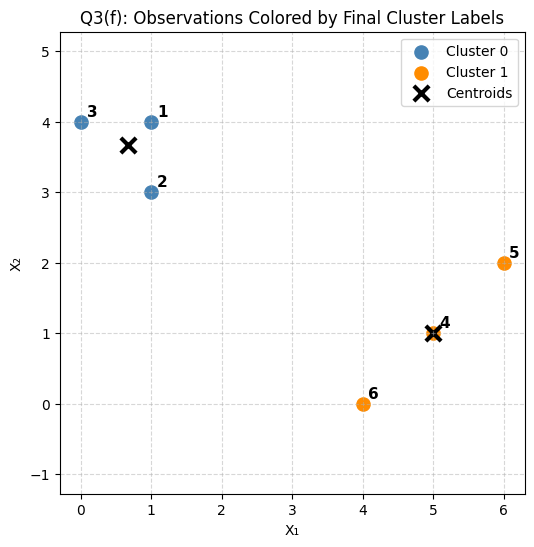

Cluster 0 members: [np.int64(1), np.int64(2), np.int64(3)]
Cluster 1 members: [np.int64(4), np.int64(5), np.int64(6)]


In [16]:
# (e)
# ---- Assume final cluster labels from best K-means solution ----
# (You can replace this with the labels obtained in your 3.(e) code)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
labels_final = kmeans.fit_predict(plot)
centroids_final = kmeans.cluster_centers_

# ---- Plot ----
plt.figure(figsize=(6, 6))

# color map for clusters {0,1}
colors = np.array(["steelblue", "darkorange"])

# scatter each cluster
for k in np.unique(labels_final):
    mask = (labels_final == k)
    plt.scatter(plot[mask, 0], plot[mask, 1],
                color=colors[k], s=90, label=f"Cluster {k}")

# plot centroids
plt.scatter(centroids_final[:, 0], centroids_final[:, 1],
            color="black", marker="x", s=120, linewidths=3, label="Centroids")

# label each observation with its ID
for i, oid in enumerate(obs_ids):
    plt.text(plot[i, 0] + 0.08, plot[i, 1] + 0.08,
             str(oid), fontsize=11, weight="bold")

plt.title("Q3(f): Observations Colored by Final Cluster Labels")
plt.xlabel("X₁")
plt.ylabel("X₂")
plt.grid(True, linestyle="--", alpha=0.5)
plt.axis("equal")
plt.legend()
plt.show()

# ---- Optional: print final cluster composition ----
for k in np.unique(labels_final):
    members = obs_ids[labels_final == k]
    print(f"Cluster {k} members: {list(members)}")